In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. tensorflow v2.10에서 v1사용하기

In [3]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v2 활성화
import numpy as np
import pandas as pd

## Tensorflow
- 데이터 흐름 그래프 (tensor 객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session으로 실행
- sess.run()을 통해 값을 확인

In [4]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'Hello, Tensorflow'


In [5]:
node1 = tf.constant(10, dtype=tf.float16)
node2 = tf.constant(20, dtype=tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [7]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [8]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1.,2.,3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [11]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([2]) # 평균0, 표준편차 1인 난수 실수 2개 (정규분포 이루는 난수)
b = tf.random_normal([1])
sess = tf.Session()
sess.run([a,b])

[array([-0.1951313 ,  0.91458863], dtype=float32),
 array([1.7496369], dtype=float32)]

In [13]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([-0.8783929], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [30]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# hypothesis : 예측값
H = W*x + b
# cost function(손실함수 = mse; 최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientdescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, w, b])
    if step%200 == 0 :
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 4.573808670043945, w: [-0.38742274], b: [-0.72376263]
200번째 cost: 0.1092761978507042, w: [-0.38742274], b: [0.12932152]
400번째 cost: 0.04172701761126518, w: [-0.38742274], b: [0.46197346]
600번째 cost: 0.015933411195874214, w: [-0.38742274], b: [0.6675323]
800번째 cost: 0.006084159482270479, w: [-0.38742274], b: [0.7945551]
1000번째 cost: 0.002323242835700512, w: [-0.38742274], b: [0.8730473]
1200번째 cost: 0.0008871189202181995, w: [-0.38742274], b: [0.9215512]
1400번째 cost: 0.0003387540637049824, w: [-0.38742274], b: [0.951523]
1600번째 cost: 0.00012934691039845347, w: [-0.38742274], b: [0.97004473]
1800번째 cost: 4.9390964704798535e-05, w: [-0.38742274], b: [0.9814895]
2000번째 cost: 1.8860991986002773e-05, w: [-0.38742274], b: [0.9885614]
2200번째 cost: 7.202650976978475e-06, w: [-0.38742274], b: [0.9929313]
2400번째 cost: 2.750275598373264e-06, w: [-0.38742274], b: [0.99563193]
2600번째 cost: 1.0506811349841882e-06, w: [-0.38742274], b: [0.99730027]
2800번째 cost: 4.017506398668047e-07, w: [-0.

In [22]:
sess.run([W,b])

[array([0.9999891], dtype=float32), array([1.0000248], dtype=float32)]

In [23]:
W_, b_ = sess.run([W,b])
W_[0], b_[0]

(0.9999891, 1.0000248)

In [24]:
def predict(x):
    return W_[0]*x+b_[0]

In [26]:
input_x = int(input('입력값은?'))
print('예측값은 ', predict(input_x))

입력값은?4
예측값은  4.999981164932251


## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [29]:
# x = np.arry([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x+1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [33]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data, y:y_data})
    if step%200 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 24.161340713500977, w: [1.4166186], b: [0.7961627]
200번째 cost: 0.00024917986593209207, w: [2.0053682], b: [0.9713069]
400번째 cost: 2.450958709232509e-05, w: [2.0016837], b: [0.99100137]
600번째 cost: 2.411992454653955e-06, w: [2.000528], b: [0.99717736]
800번째 cost: 2.373957102008717e-07, w: [2.0001657], b: [0.99911433]
1000번째 cost: 2.33145893702158e-08, w: [2.000052], b: [0.9997221]
1200번째 cost: 2.293472745051872e-09, w: [2.0000165], b: [0.9999129]
1400번째 cost: 2.36707375922407e-10, w: [2.0000055], b: [0.999972]
1600번째 cost: 3.1877788603251744e-11, w: [2.0000021], b: [0.99998945]
1800번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2000번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2200번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2400번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2600번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2800번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213

In [34]:
# 예측하기
sess.run(H, feed_dict={x:5})

array([11.000001], dtype=float32)

In [35]:
sess.run(H, feed_dict={x:np.array([5,6,7])})

array([11.000001, 13.000002, 15.000004], dtype=float32)

In [39]:
type([5,6,7]), type(np.array([5,6,7]))

(list, numpy.ndarray)

# 2.3 scale이 다른 데이터의 linear regression 구현 (scale 조정 x)

In [41]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(1001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data, y:y_data})
    if step%200 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 3508.753173828125, w: [6.4401855], b: [-0.3838833]
200번째 cost: 265.6599426269531, w: [13.231541], b: [1.803196]
400번째 cost: 265.61529541015625, w: [13.1795845], b: [2.0809002]
600번째 cost: 265.6108703613281, w: [13.16329], b: [2.1679964]
800번째 cost: 265.61041259765625, w: [13.158179], b: [2.1953118]
1000번째 cost: 265.61041259765625, w: [13.156576], b: [2.203878]


In [42]:
# cost값이 멈춤 : local 최소값

## 2.4 scale이 다른 데이터의 linear regression을 구현(조정 o)
### scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization (정규화): 0~1로 조정
                       X - Xmin
      normalization = ____________
                       Xmax - Xmin
          * 위의 식을 써도 되지만 라이브러리를 사용(sklearn.preprocessing.MinMaxScaler이용)
- standardization (표준화): 평균 0, 표준편차 1로 조정
                         X - Xmean(평균)
      standardization = ________________
                           Xstd (표준편차)
          * 위의 식을 써도 되지만 라이브러리를 사용(sklearn.preprocessing.StandardScaler이용)

In [49]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min())/(x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min())/(y_data.max() - y_data.min())
print(scaled_x_data,'\n', scaled_y_data)

[0.         0.11111111 0.44444444 0.77777778 1.        ] 
 [0.         0.13043478 0.70652174 0.83695652 1.        ]


In [73]:
# 라이브러리를 이용한 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1,1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data, y_data])
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaler_y = MinMaxScaler() # y_data를 정규화시킬 객체
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [74]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12000):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data, y:scaled_y_data})
    if step%500 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 0.612799882888794, w: [1.1231313], b: [0.7666885]
500번째 cost: 0.01044379360973835, w: [0.94559354], b: [0.09733973]
1000번째 cost: 0.009919585660099983, w: [0.9884693], b: [0.07469078]
1500번째 cost: 0.009868691675364971, w: [1.0018286], b: [0.06763465]
2000번째 cost: 0.009863755665719509, w: [1.0059907], b: [0.06543614]
2500번째 cost: 0.009863274171948433, w: [1.0072877], b: [0.06475123]
3000번째 cost: 0.009863226674497128, w: [1.0076914], b: [0.06453823]
3500번째 cost: 0.009863225743174553, w: [1.0078124], b: [0.06447316]
4000번째 cost: 0.009863222017884254, w: [1.0078529], b: [0.06445174]
4500번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
5000번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
5500번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
6000번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
6500번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
7000번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
750

In [75]:
# 예측 : 모델에 sclae 조정된 값으로 예측 => scale조정된 y값
scaled_input = scaler_x.transform(np.array([[4],
                                           [7]]))
print('모델 예측을 위한 입력 :', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :', scaled_output, sep='\n')
print('결과 ', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.33333333]
 [0.66666667]]
모델 예측 결과 :
[[0.4004023]
 [0.7363536]]
결과 
[[39.837013]
 [70.74453 ]]


In [76]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

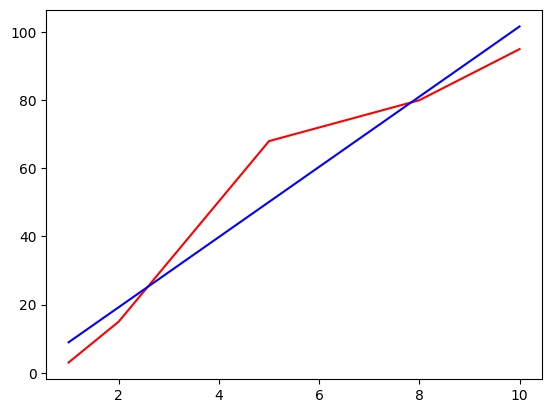

In [77]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [82]:
# 라이브러리를 사용하여 표준화(standardscaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1,1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12000):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data, y:scaled_y_data})
    if step%500 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]
0번째 cost: 2.4903039932250977, w: [0.46039817], b: [-1.4400252]
500번째 cost: 0.06268569082021713, w: [0.9681291], b: [-5.9061287e-05]
1000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-2.2081583e-08]
1500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
2000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
2500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
3000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
3500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
4000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
4500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
5000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
5500번째 cost: 0.06268571317195892, w: [0.96814847], b: [

모델 예측을 위한 입력 :
[[-0.34992711]
 [ 0.52489066]]
모델 예측 결과 :
[[-0.33878142]
 [ 0.5081721 ]]
결과 
[[39.836754]
 [70.74487 ]]


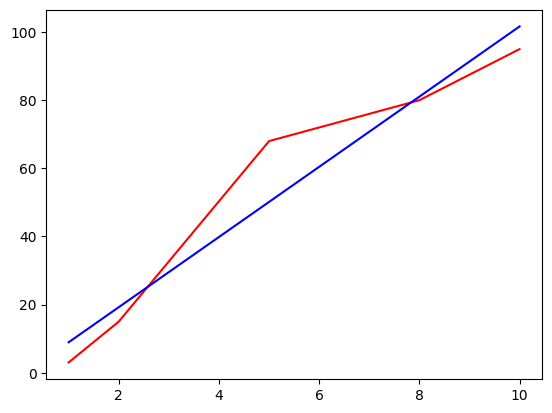

In [80]:
# 예측 : 모델에 sclae 조정된 값으로 예측 => scale조정된 y값
scaled_input = scaler_x.transform(np.array([[4],
                                           [7]]))
print('모델 예측을 위한 입력 :', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :', scaled_output, sep='\n')
print('결과 ', scaler_y.inverse_transform(scaled_output), sep='\n')

# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')